#### IEEE-CIS Fraud Detection

This notebook demonstrates basic Python code execution and guides you through the first steps of working with the IEEE-CIS Fraud Detection dataset.

In [24]:
# Import Required Libraries
import pandas as pd
import numpy as np

- Download the dataset from Kaggle (https://www.kaggle.com/c/ieee-fraud-detection/data).
- Unzip the files and place them in your project directory.
- Load the data in Python using pandas:

In [25]:
# Load transaction and identity data
location = r'D:\AI-DATASETS\02-MISC-large\ieee_cis_fraud_detection'

train           = pd.read_csv(f'{location}/train_transaction.csv')
test            = pd.read_csv(f'{location}/test_transaction.csv')
train_identity  = pd.read_csv(f'{location}/train_identity.csv')
test_identity   = pd.read_csv(f'{location}/test_identity.csv')

In [26]:
train.shape, test.shape, train_identity.shape, test_identity.shape

((590540, 394), (506691, 393), (144233, 41), (141907, 41))

#### Analyzing Data Shapes

**What to look for:**
- The number of rows in `train` and `train_identity` may differ (not all transactions have identity info).
- The number of columns in `train` and `test` should be similar (except for the target column).
- If `train_identity` or `test_identity` has fewer rows, merging will introduce missing values for identity features.

**Example interpretation:**
- If `train.shape = (590540, 394)` and `train_identity.shape = (144233, 41)`, only about 24% of training transactions have identity info.
- This means you should expect many NaNs in identity columns after merging.

**Note:**
- The training set has 394 columns! This is a very high-dimensional dataset, which makes feature selection, dimensionality reduction, and careful EDA especially important.

This analysis helps you understand the structure and completeness of your data before further processing.

#### Basic Data Exploration

In [27]:
# preview data
display(train.head())

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
# Get all column names as a list
column_names = list(train.columns)
print(column_names)

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

#### What is the identity CSV?

The identity CSV files (`train_identity.csv` and `test_identity.csv`) provide extra information about some transactions, such as:
- Device type and info (e.g., device type, device info, browser, OS)
- Network-related features (e.g., IP address, email domain, R_emaildomain, P_emaildomain)
- Anonymized fields (e.g., id_01 to id_38)

Not every transaction has a corresponding identity row, so after merging, many transactions will have missing values for these features.

**Purpose:**
- Identity features add context about the user and device, helping models capture behavioral and device-based fraud patterns. 
- Even though most columns are anonymized, they can still be useful for feature engineering and improving model performance.

In [29]:
# Merge identity data with transaction data
train_merged = train.merge(train_identity, how='left', on='TransactionID')
test_merged  = test.merge(test_identity,   how='left', on='TransactionID')

#### Why are many columns NULL after merging identity data?

After merging, many columns are NULL in the train and test sets because not every transaction has a corresponding row in the identity CSV. This is expected and normal for this dataset.

- Identity information is only available for a subset of transactions.
- For transactions without identity info, all identity columns will be NaN after merging.

**How to handle this:**
- Use missingness as a feature (e.g., create a 'has_identity_info' column).
- Impute missing values (e.g., with a placeholder, mean, or mode) or use models that handle NaNs.
- Consider dropping identity columns with too many missing values.

This is a common scenario in real-world data and can be handled with appropriate preprocessing and feature engineering.

In [30]:
# Analyze the identity CSV table
print('Identity columns:', list(train_identity.columns))
print('\nSample rows:')
display(train_identity.head())

print('\nMissing value ratio:')
print(train_identity.isnull().mean().sort_values(ascending=False))

print('\nColumn types:')
print(train_identity.dtypes.value_counts())

Identity columns: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Sample rows:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS



Missing value ratio:
id_24            0.967088
id_25            0.964419
id_07            0.964259
id_08            0.964259
id_21            0.964231
id_26            0.964204
id_23            0.964162
id_27            0.964162
id_22            0.964162
id_18            0.687221
id_03            0.540161
id_04            0.540161
id_33            0.491871
id_09            0.480521
id_10            0.480521
id_30            0.462224
id_32            0.462079
id_34            0.460560
id_14            0.445037
DeviceInfo       0.177262
id_13            0.117262
id_16            0.103257
id_06            0.051084
id_05            0.051084
id_20            0.034472
id_19            0.034077
id_17            0.033723
id_31            0.027393
DeviceType       0.023732
id_02            0.023303
id_28            0.022568
id_29            0.022568
id_11            0.022568
id_15            0.022519
id_35            0.022519
id_36            0.022519
id_37            0.022519
id_38           

#### Missing value analysis

In [31]:
# Missing value analysis for train, train_merged, test, and test_merged
def missing_value_summary(df, name):
    print(f'\nMissing value ratio in {name}:')
    missing = df.isnull().mean().sort_values(ascending=False)
    print(missing[missing > 0].head(20))
    print(f'Total columns with missing values: {(missing > 0).sum()} / {len(missing)}')

missing_value_summary(train, 'train')
missing_value_summary(train_merged, 'train_merged')
missing_value_summary(test, 'test')
missing_value_summary(test_merged, 'test_merged')


Missing value ratio in train:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V139     0.861237
V162     0.861237
V161     0.861237
V154     0.861237
V138     0.861237
V158     0.861237
V157     0.861237
V163     0.861237
V156     0.861237
V155     0.861237
V149     0.861237
dtype: float64
Total columns with missing values: 374 / 394

Missing value ratio in train_merged:
dist2    0.936284
D7       0.934099
D13      0.895093
D14      0.894695
D12      0.890410
D6       0.876068
D9       0.873123
D8       0.873123
V153     0.861237
V139     0.861237
V162     0.861237
V161     0.861237
V154     0.861237
V138     0.861237
V158     0.861237
V157     0.861237
V163     0.861237
V156     0.861237
V155     0.861237
V149     0.861237
dtype: float64
Total columns with missing values: 374 / 394

Missing value ratio in train_merged:
id_24    0.991962
id_25    0.991310
id_07    0.991271

#### Target distribution

In [32]:
# Target distribution in train set
print('Target distribution (isFraud):')
print(train['isFraud'].value_counts(normalize=True))

Target distribution (isFraud):
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


#### Exploratory Data Analysis

In [33]:
# Separate numerical and categorical features in train_merged
numerical_features   = train_merged.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train_merged.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Numerical features ({len(numerical_features)}):', numerical_features[:10], '...')
print(f'Categorical features ({len(categorical_features)}):', categorical_features[:10], '...')

Numerical features (403): ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2'] ...
Categorical features (31): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5'] ...


In [34]:
# (Optional) Check if test_merged has the same types of features
test_num_features = test_merged.select_dtypes(include=[np.number]).columns.tolist()
test_cat_features = test_merged.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Test numerical features ({len(test_num_features)}):', test_num_features[:10], '...')
print(f'Test categorical features ({len(test_cat_features)}):', test_cat_features[:10], '...')

Test numerical features (402): ['TransactionID', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1'] ...
Test categorical features (31): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5'] ...


#### Anonymized columns

In [37]:
# List all non-anonymized columns in train_merged
import re
def is_anonymized(col):
    return bool(re.match(r'^V\d+$', col)) or bool(re.match(r'^id_\d+$', col))
non_anonymized_cols = [col for col in train_merged.columns if not is_anonymized(col)]
print(f'Non-anonymized columns ({len(non_anonymized_cols)}):')
non_anonymized_cols

Non-anonymized columns (57):


['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'DeviceType',
 'DeviceInfo']

In [39]:
train_merged[non_anonymized_cols].sample(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,M2,M3,M4,M5,M6,M7,M8,M9,DeviceType,DeviceInfo
32905,3019905,0,830475,280.00,W,2485,555.0,150.0,visa,226.0,...,NaN,NaN,M0,F,F,NaN,NaN,NaN,NaN,NaN
199320,3186320,0,4507380,107.95,W,7919,194.0,150.0,mastercard,202.0,...,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN
551739,3538739,0,14581652,59.00,W,5033,269.0,150.0,mastercard,224.0,...,T,T,M0,T,F,F,F,T,NaN,NaN
355764,3342764,0,8804392,54.50,W,15484,418.0,150.0,visa,226.0,...,T,T,M0,F,F,F,F,T,NaN,NaN
173931,3160931,0,3777717,25.95,W,9480,170.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,F,NaN,NaN,NaN,NaN,NaN


In [51]:
# Display 10 random sample rows for TransactionID and card1 to card6, suppressing the row index
display(train_merged[['TransactionID', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6']].sample(10).reset_index(drop=True))

,TransactionID,card1,card2,card3,card4,card5,card6
0,3277339,1589,390.0,150.0,mastercard,224.0,debit
1,3006426,2616,NaN,150.0,discover,102.0,credit
2,3174779,13149,161.0,150.0,mastercard,219.0,credit
3,3216517,16075,514.0,150.0,mastercard,102.0,credit
4,3225540,1974,111.0,150.0,visa,226.0,debit
5,3156635,7835,361.0,150.0,visa,226.0,debit
6,3494558,9043,170.0,150.0,visa,195.0,credit
7,3113834,15497,490.0,150.0,visa,226.0,debit
8,3459650,6170,174.0,150.0,visa,226.0,debit
9,3094242,12544,321.0,150.0,visa,226.0,debit


In [52]:
# Value counts for card4 and card6
print('card4 value counts:')
print(train_merged['card4'].value_counts(dropna=False))

print('\ncard6 value counts:')
print(train_merged['card6'].value_counts(dropna=False))

card4 value counts:
card4
visa                384767
mastercard          189217
american express      8328
discover              6651
NaN                   1577
Name: count, dtype: int64

card6 value counts:
card6
debit              439938
credit             148986
NaN                  1571
debit or credit        30
charge card            15
Name: count, dtype: int64


#### card4  

In [55]:
# Cardinality and distribution for card4
print('card4 unique values:', train_merged['card4'].nunique(dropna=False))
print('card4 value counts (normalized):')
print(train_merged['card4'].value_counts(normalize=True, dropna=False))

card4 unique values: 5
card4 value counts (normalized):
card4
visa                0.651551
mastercard          0.320414
american express    0.014102
discover            0.011263
NaN                 0.002670
Name: proportion, dtype: float64



**Interpretation:**
- `card4` is low-cardinality and dominated by "visa" and "mastercard".
- The presence of "american express" and "discover" is small but non-negligible.
- Very few missing values (NaN).

**Conclusion:**
- `card4` is suitable for modeling as a categorical feature. Its distribution is not overly imbalanced, and the presence of multiple brands may help capture fraud patterns related to card type.

Fraud rate by card4:
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64


C:\Users\bhupe\AppData\Local\Temp\ipykernel_28588\2017829366.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='viridis')


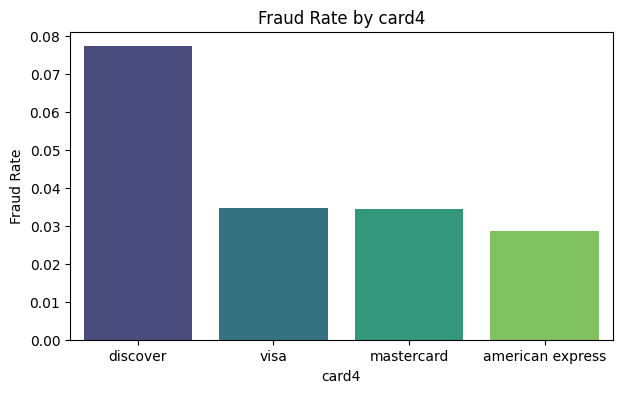

In [57]:
# Fraud rate by card4 and bar plot visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate fraud rate by card4
fraud_rate = train_merged.groupby('card4')['isFraud'].mean().sort_values(ascending=False)

print('Fraud rate by card4:')
print(fraud_rate)

# Bar plot of fraud rate by card4
plt.figure(figsize=(7,4))
sns.barplot(x=fraud_rate.index, y=fraud_rate.values, palette='viridis')
plt.title('Fraud Rate by card4')
plt.ylabel('Fraud Rate')
plt.xlabel('card4')
plt.show()

#### Fraud Rate by card4
- **discover:** 7.7%
- **visa:** 3.5%
- **mastercard:** 3.4%
- **american express:** 2.9%

**Insights:**
- Transactions with "discover" cards have a notably higher fraud rate than other brands.
- "visa" and "mastercard" have similar, moderate fraud rates.
- "american express" has the lowest fraud rate among the listed brands.

**Conclusion:**
- `card4` is a useful feature for modeling, as fraud rates differ by card brand.

**How is fraud rate calculated?**
For each card brand (e.g., "visa", "mastercard"), the fraud rate is the proportion of transactions labeled as fraud (`isFraud == 1`) out of all transactions for that brand.

Mathematically:
$$
\text{Fraud Rate}_{\text{card4}=x} = \frac{\text{Number of frauds for card4}=x}{\text{Total transactions for card4}=x}
$$

In code:
```python
fraud_rate = train_merged.groupby('card4')['isFraud'].mean()
```
This groups the data by `card4` and computes the average of `isFraud` (which is 1 for fraud, 0 for non-fraud), resulting in the fraud rate for each card type.

#### Fraud Rate by card6

- The table and plot above show the fraud rate for each card6 category.

**How is fraud rate calculated?**
For each card type (e.g., "debit", "credit"), the fraud rate is the proportion of transactions labeled as fraud (`isFraud == 1`) out of all transactions for that type.

Mathematically:
$$
\text{Fraud Rate}_{\text{card6}=x} = \frac{\text{Number of frauds for card6}=x}{\text{Total transactions for card6}=x}
$$

In code:
```python
fraud_rate_card6 = train_merged.groupby('card6')['isFraud'].mean()
```
This groups the data by `card6` and computes the average of `isFraud` (which is 1 for fraud, 0 for non-fraud), resulting in the fraud rate for each card type.

**Insights:**
- Compare the fraud rates across card6 categories to identify which card types are more susceptible to fraud.
- Use these insights to inform feature engineering and modeling.

Fraud rate by card6:
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


C:\Users\bhupe\AppData\Local\Temp\ipykernel_28588\871799246.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate_card6.index, y=fraud_rate_card6.values, palette='viridis')


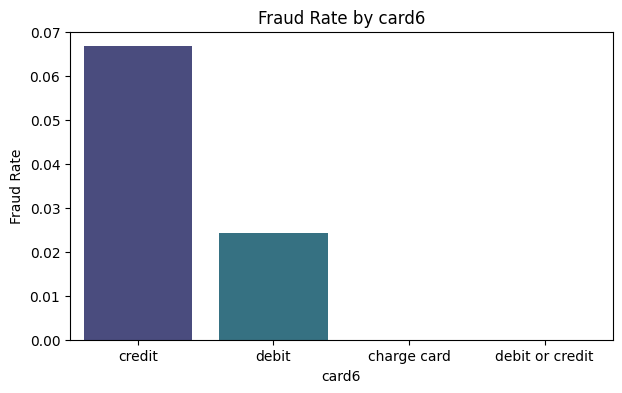

In [58]:
# Fraud rate by card6 and bar plot visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate fraud rate by card6
fraud_rate_card6 = train_merged.groupby('card6')['isFraud'].mean().sort_values(ascending=False)

print('Fraud rate by card6:')
print(fraud_rate_card6)

# Bar plot of fraud rate by card6
plt.figure(figsize=(7,4))
sns.barplot(x=fraud_rate_card6.index, y=fraud_rate_card6.values, palette='viridis')
plt.title('Fraud Rate by card6')
plt.ylabel('Fraud Rate')
plt.xlabel('card6')
plt.show()

In [59]:
# Cardinality and distribution for card6
print('card6 unique values:', train_merged['card6'].nunique(dropna=False))
print('card6 value counts (normalized):')
print(train_merged['card6'].value_counts(normalize=True, dropna=False))

card6 unique values: 5
card6 value counts (normalized):
card6
debit              0.744976
credit             0.252288
NaN                0.002660
debit or credit    0.000051
charge card        0.000025
Name: proportion, dtype: float64


**Interpretation:**
- `card6` is a low-cardinality categorical feature with 5 unique values (including NaN).
- The vast majority of transactions are "debit" (74.5%) or "credit" (25.2%).
- Very few transactions are "debit or credit" (0.005%), "charge card" (0.0025%), or missing (0.27%).

**Conclusion:**
- `card6` is suitable for modeling as a categorical feature. Its distribution is highly imbalanced toward "debit" and "credit", but the rare categories and missing values may still provide useful signals for fraud detection.

#### card3

card3 min: 100.0
card3 max: 231.0
card3 mean: 153.19492508170975
card3 median: 150.0
card3 missing values: 1565


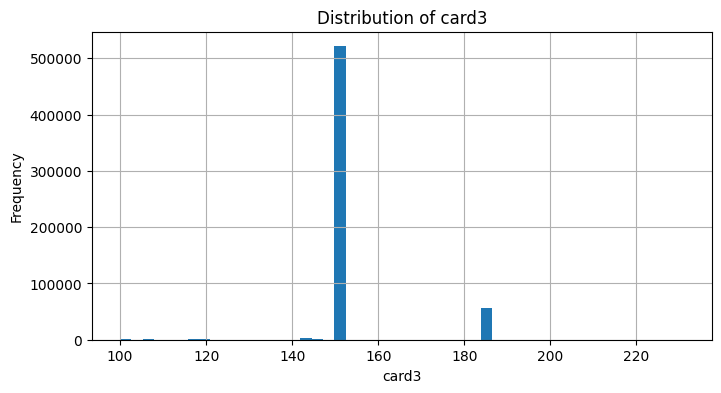

In [60]:
# Numeric distribution and missing values for card3
print('card3 min:', train_merged['card3'].min())
print('card3 max:', train_merged['card3'].max())
print('card3 mean:', train_merged['card3'].mean())
print('card3 median:', train_merged['card3'].median())
print('card3 missing values:', train_merged['card3'].isnull().sum())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
train_merged['card3'].hist(bins=50)
plt.title('Distribution of card3')
plt.xlabel('card3')
plt.ylabel('Frequency')
plt.show()

**Interpretation of card3 statistics:**
- `card3` ranges from 100 to 231, with a mean of about 153 and a median of 150.
- The values are integers, suggesting `card3` is likely a code (e.g., location, bank branch, or institution code) rather than a continuous variable.
- The distribution is likely discrete, with certain values much more common than others (as seen in the value counts).
- There are 1,565 missing values, which is a small fraction compared to the dataset size, but should still be handled appropriately (e.g., imputation, separate category, or missing indicator).

**What this could mean:**
- `card3` encodes some property of the card or transaction, such as the issuing bank, branch, or region. The specific meaning is not public, but patterns in its values may relate to fraud risk (e.g., certain codes being more/less risky).
- The relatively narrow range and integer values support the idea of a categorical code rather than a measurement.
- If some codes have much higher or lower fraud rates, this feature could be very useful for modeling.
- Handling missing values is important: you can treat them as a separate category, impute with the mode, or add a missing indicator feature.

#### card5
- **Card5** is another card-related feature. Let's analyze its cardinality, distribution, numeric statistics, missing values, and relationship to fraud, similar to card3.

**Interpretation:**
- `card5` is a numeric/integer feature, likely representing a code (e.g., bank, region, or account type).
- The output above will show its unique values, distribution, summary statistics, and missing values.
- The fraud rate analysis for the most common values will help identify if certain codes are more associated with fraud.

**Conclusion:**
- Depending on its cardinality and distribution, `card5` may be suitable for modeling as a categorical or numeric feature. Handling missing values and rare codes appropriately is important.

Fraud rate by card5 (top 10 values):
card5
137.0    0.147184
138.0    0.085221
102.0    0.062945
219.0    0.057537
195.0    0.040189
224.0    0.038669
226.0    0.029516
117.0    0.013646
166.0    0.011026
126.0    0.010196
Name: isFraud, dtype: float64


C:\Users\bhupe\AppData\Local\Temp\ipykernel_28588\3822413418.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_rate_card5.index.astype(str), y=fraud_rate_card5.values, palette='viridis')


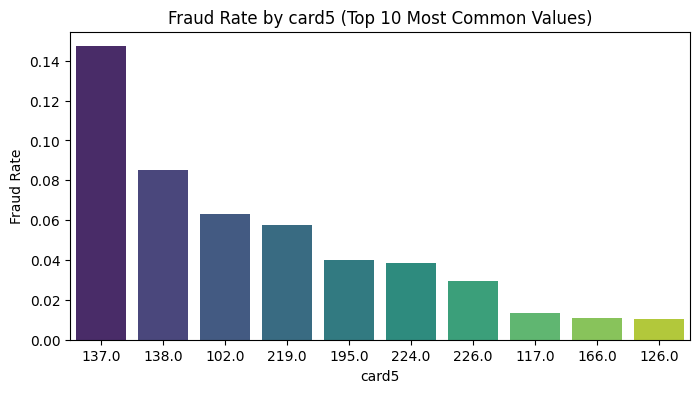

In [61]:
# Fraud rate by card5 and bar plot visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate fraud rate by card5 (show top 10 most common values)
top_card5 = train_merged['card5'].value_counts().head(10).index
fraud_rate_card5 = train_merged[train_merged['card5'].isin(top_card5)].groupby('card5')['isFraud'].mean().sort_values(ascending=False)

print('Fraud rate by card5 (top 10 values):')
print(fraud_rate_card5)

# Bar plot of fraud rate by card5 (top 10)
plt.figure(figsize=(8,4))
sns.barplot(x=fraud_rate_card5.index.astype(str), y=fraud_rate_card5.values, palette='viridis')
plt.title('Fraud Rate by card5 (Top 10 Most Common Values)')
plt.ylabel('Fraud Rate')
plt.xlabel('card5')
plt.show()

card5 min: 100.0
card5 max: 237.0
card5 mean: 199.27889697943476
card5 median: 226.0
card5 missing values: 4259


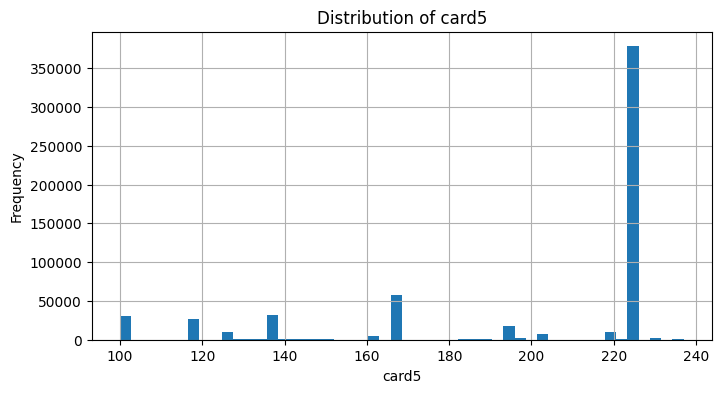

In [62]:
# Numeric distribution and missing values for card5
print('card5 min:', train_merged['card5'].min())
print('card5 max:', train_merged['card5'].max())
print('card5 mean:', train_merged['card5'].mean())
print('card5 median:', train_merged['card5'].median())
print('card5 missing values:', train_merged['card5'].isnull().sum())

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
train_merged['card5'].hist(bins=50)
plt.title('Distribution of card5')
plt.xlabel('card5')
plt.ylabel('Frequency')
plt.show()

In [63]:
# Cardinality and distribution for card5
print('card5 unique values:', train_merged['card5'].nunique(dropna=False))
print('card5 value counts (normalized):')
print(train_merged['card5'].value_counts(normalize=True, dropna=False))

card5 unique values: 120
card5 value counts (normalized):
card5
226.0    0.502161
224.0    0.138031
166.0    0.096759
102.0    0.049285
117.0    0.043928
           ...   
221.0    0.000002
167.0    0.000002
115.0    0.000002
165.0    0.000002
234.0    0.000002
Name: proportion, Length: 120, dtype: float64


#### some more features

- 'addr1',
- 'addr2',
- 'dist1',
- 'dist2',
- 'P_emaildomain',
- 'R_emaildomain',

**Sample rows interpretation:**
- `addr1` and `addr2`: Numeric codes, likely representing geographic or billing address regions. `addr2` is almost always 87, suggesting low cardinality or a default value.
- `dist1` and `dist2`: Numeric, often with many missing values. These may represent distances (e.g., between billing and shipping addresses, or to a reference location). `dist2` is frequently missing.
- `P_emaildomain` and `R_emaildomain`: Email domains for purchaser and recipient. Common domains are `gmail.com`, `yahoo.com`, `hotmail.com`, with many missing values (NaN). Sometimes both are present, sometimes only one, sometimes neither.

**What this means:**
- These features are a mix of categorical (email domains), numeric/categorical codes (addr1, addr2), and possibly continuous or discrete numeric (dist1, dist2).
- There are many missing values, especially for `dist2` and `R_emaildomain`.
- `addr2` is almost always the same value, so it may have limited predictive power.
- Email domains could be useful for detecting fraud patterns (e.g., free email providers vs. corporate domains).

In [65]:
# Display 10 random sample rows for address and email features, suppressing the row index
display(train_merged[['addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain']].sample(10).reset_index(drop=True))

,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain
0,NaN,NaN,NaN,NaN,hotmail.com,hotmail.com
1,498.0,87.0,NaN,NaN,yahoo.com,NaN
2,325.0,87.0,NaN,NaN,gmail.com,gmail.com
3,436.0,87.0,NaN,NaN,gmail.com,NaN
4,502.0,87.0,NaN,NaN,gmail.com,NaN
5,NaN,NaN,NaN,4.0,hotmail.com,hotmail.com
6,123.0,87.0,12.0,NaN,NaN,NaN
7,327.0,87.0,224.0,NaN,yahoo.com,NaN
8,337.0,87.0,NaN,NaN,NaN,yahoo.com
9,231.0,87.0,NaN,NaN,gmail.com,NaN


#### Considerations for Selecting ML Algorithms

When choosing machine learning algorithms we need to keep these points in mind:

1. **High Dimensionality:**
   - The dataset has 400+ features, many anonymized.
   - Prefer algorithms that handle high-dimensional data well (tree-based models, regularized linear models).

2. **Mixed Data Types:**
   - Numeric, categorical, and many missing values are present.
   - Algorithms that natively handle categorical variables (CatBoost, LightGBM) or are robust to missing data (tree-based models) are advantageous.

3. **Class Imbalance:**
   - Fraud is rare (imbalanced target).
   - Use algorithms that support class weighting or sampling (Random Forest, XGBoost, LightGBM, Logistic Regression with class_weight).

4. **Scalability:**
   - The dataset is large.
   - Efficient algorithms (gradient boosting, random forest, logistic regression) are practical.

5. **Interpretability:**
   - For explainability, start with logistic regression or decision trees.
   - For best performance, use ensemble methods (Random Forest, XGBoost, LightGBM).

6. **Baseline and Advanced Models:**
   - Start with logistic regression or decision tree for baseline.
   - Move to Random Forest, XGBoost, or LightGBM for better performance.

**Summary:**
Tree-based ensemble models (Random Forest, XGBoost, LightGBM, CatBoost) are most popular for this type of data, but always start with a simple baseline for comparison.

#### Missing Values and Imputation

- The dataset contains many missing values, especially after merging transaction and identity data.
- Some columns (especially identity and anonymized features) have a very high proportion of missing values.
- Handling missing values is essential before model building, especially for algorithms like logistic regression that do not support NaNs.

**Imputation Considerations:**
- Manual imputation for hundreds of columns is impractical.
- Automated imputation (using tools like scikit-learn's `SimpleImputer` or `ColumnTransformer`) can efficiently fill missing values for all columns at once.
- However, automated imputation can be a 'black box'—it may not be clear which values are being filled and how, especially for anonymized columns.
- To maintain transparency:
    - Always review and log missing value statistics before and after imputation.
    - Document the imputation strategy (e.g., mean/median for numeric, most frequent/constant for categorical).
    - For important features, consider manual review or domain-informed imputation.

**Best Practice:**
- Combine automated imputation for efficiency with careful documentation and review to ensure data quality and interpretability.

#### Step-up Modeling Approach

A practical modeling strategy for this dataset is to use a step-up approach:

1. **Decision Tree (DT) as Baseline:**
   - Simple, interpretable, and fast to train.
   - Helps establish a baseline performance and understand feature importance.

2. **Random Forest (RF) as Intermediate Solution:**
   - Ensemble of decision trees, more robust and accurate than a single tree.
   - Handles high-dimensional data and missing values well.
   - Provides better generalization and feature importance insights.

3. **XGBoost or CatBoost as Final Solution:**
   - Advanced gradient boosting algorithms, often achieve state-of-the-art results on tabular data.
   - Handle missing values, categorical features (CatBoost), and class imbalance efficiently.
   - Require more tuning but can deliver the best performance.

**Summary:**
- Start simple and build up to more complex models.
- Each step provides insights and performance improvements, while allowing you to debug and interpret results at each stage.

In [78]:
# remove ID-type columns from train_merged
import re
def is_id_col(col):
    # Remove TransactionID and any column that looks like an ID (case-insensitive, ends with 'id', or matches 'id_\d+')
    return (col.lower() == 'transactionid' or 
            col.lower().endswith('id') or 
            bool(re.match(r'^id_\d+$', col, re.IGNORECASE)))

id_cols = [col for col in train_merged.columns if is_id_col(col)]
print('ID-type columns to remove:', id_cols)

ID-type columns to remove: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [76]:
train_merged[['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06']].sample(5)

,id_01,id_02,id_03,id_04,id_05,id_06
273299,-5.0,389207.0,NaN,NaN,0.0,0.0
18757,-5.0,28402.0,NaN,NaN,0.0,0.0
150057,0.0,186472.0,0.0,0.0,2.0,-9.0
262591,NaN,NaN,NaN,NaN,NaN,NaN
322584,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# Take a sample of 10,000 rows for faster experimentation
train_sample = train_merged.sample(n=10000, random_state=42)

# Target/Feature Split: Separate the target variable (isFraud) from features
dt_target   = train_sample['isFraud']
dt_features = train_sample.drop(columns=['isFraud'])

print('Sampled features shape:', dt_features.shape)
print('Sampled target shape:', dt_target.shape)

Sampled features shape: (10000, 433)
Sampled target shape: (10000,)


In [97]:
# Convert all categorical columns to string (including NaN as 'nan')
for col in categorical_features:
    if col in dt_features.columns:
        dt_features[col] = dt_features[col].astype(str)

In [84]:
#!pip install catboost

In [98]:
# CatBoost baseline model with native categorical support
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [99]:
# Split data for quick baseline (stratified, 70/30)
X_train, X_val, y_train, y_val = train_test_split(
    dt_features, dt_target, test_size=0.3, stratify=dt_target, random_state=42)

In [100]:
# Find categorical feature indices (CatBoost accepts indices or names)
cat_features = [X_train.columns.get_loc(col) for col in categorical_features if col in X_train.columns]

In [101]:
# CatBoost Pool objects (optional, but allows passing categorical info)
train_pool = Pool(X_train,  y_train,    cat_features=cat_features)
val_pool   = Pool(X_val,    y_val,      cat_features=cat_features)

In [102]:
# Fit CatBoost baseline model
cat_model = CatBoostClassifier(
    iterations      =100,
    learning_rate   =0.1,
    depth           =6,
    cat_features    =cat_features,
    verbose         =20,
    random_seed     =42,
    eval_metric     ='AUC'
)

In [103]:
cat_model.fit(train_pool, eval_set=val_pool, use_best_model=True)

0:	test: 0.5536113	best: 0.5536113 (0)	total: 241ms	remaining: 23.8s
20:	test: 0.8538515	best: 0.8542594 (19)	total: 1.95s	remaining: 7.34s
20:	test: 0.8538515	best: 0.8542594 (19)	total: 1.95s	remaining: 7.34s
40:	test: 0.8627782	best: 0.8628440 (39)	total: 3.64s	remaining: 5.24s
40:	test: 0.8627782	best: 0.8628440 (39)	total: 3.64s	remaining: 5.24s
60:	test: 0.8672358	best: 0.8674727 (58)	total: 5.38s	remaining: 3.44s
60:	test: 0.8672358	best: 0.8674727 (58)	total: 5.38s	remaining: 3.44s
80:	test: 0.8638572	best: 0.8674727 (58)	total: 7.25s	remaining: 1.7s
80:	test: 0.8638572	best: 0.8674727 (58)	total: 7.25s	remaining: 1.7s
99:	test: 0.8622650	best: 0.8674727 (58)	total: 9.01s	remaining: 0us

bestTest = 0.867472654
bestIteration = 58

Shrink model to first 59 iterations.
99:	test: 0.8622650	best: 0.8674727 (58)	total: 9.01s	remaining: 0us

bestTest = 0.867472654
bestIteration = 58

Shrink model to first 59 iterations.


In [108]:
# Evaluate
val_pred = cat_model.predict_proba(X_val)[:,1]

from sklearn.metrics import roc_auc_score, accuracy_score

auc = roc_auc_score(y_val, val_pred)
val_pred_label = (val_pred >= 0.5).astype(int)
acc = accuracy_score(y_val, val_pred_label)
print(f'Validation AUC: {auc:.4f}')
print(f'Validation Accuracy: {acc:.4f}')

Validation AUC: 0.8675
Validation Accuracy: 0.9720


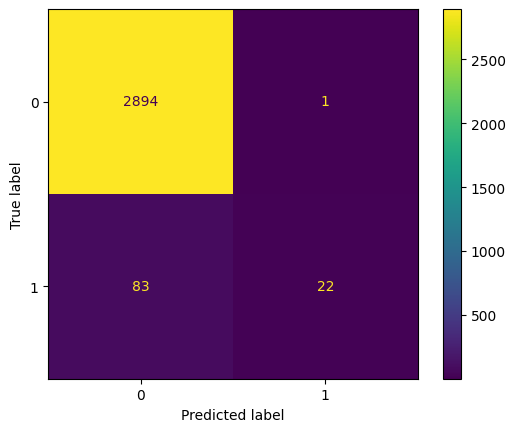

In [109]:
# Confusion matrix for CatBoost predictions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use 0.5 threshold for binary prediction
val_pred_label = (val_pred >= 0.5).astype(int)
cm   = confusion_matrix(y_val, val_pred_label)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [110]:
# Class-wise precision and recall
from sklearn.metrics import precision_score, recall_score

precision_0 = precision_score(y_val, val_pred_label, pos_label=0)
precision_1 = precision_score(y_val, val_pred_label, pos_label=1)
recall_0 = recall_score(y_val, val_pred_label, pos_label=0)
recall_1 = recall_score(y_val, val_pred_label, pos_label=1)
print(f'Precision (class 0): {precision_0:.4f}')
print(f'Precision (class 1): {precision_1:.4f}')
print(f'Recall (class 0): {recall_0:.4f}')
print(f'Recall (class 1): {recall_1:.4f}')

Precision (class 0): 0.9721
Precision (class 1): 0.9565
Recall (class 0): 0.9997
Recall (class 1): 0.2095


**Interpretation of Precision and Recall:**
- **Precision (class 1):** Of all transactions predicted as fraud, what fraction were actually fraud? High precision means few false positives (legitimate transactions incorrectly flagged as fraud).
- **Recall (class 1):** Of all actual frauds, what fraction did the model correctly identify? High recall means few false negatives (fraud cases missed by the model).
- **Precision (class 0):** Of all transactions predicted as non-fraud, what fraction were actually non-fraud?
- **Recall (class 0):** Of all actual non-fraud transactions, what fraction did the model correctly identify?
- In fraud detection, **recall for class 1 (fraud)** is often prioritized, as missing a fraud case can be more costly than a false alarm. However, high recall with very low precision can overwhelm investigators with false positives, so a balance is needed.
- Use these metrics to tune your model and threshold for the best trade-off between catching fraud and minimizing false alerts.

#### what do we do now?


**Next Actions:**

1. Tune the classification threshold to improve recall for fraud (class 1).

2. Try class weighting or scale_pos_weight in CatBoost to give more importance to fraud cases.

3. Engineer new features (e.g., missing value indicators, frequency encoding, feature interactions).

4. Remove or combine low-importance or highly correlated features.

5. Tune CatBoost hyperparameters (iterations, depth, learning rate, regularization, etc.).

6. Try other models (Random Forest, XGBoost, LightGBM) for comparison.

7. Use oversampling (SMOTE) or undersampling to balance the classes if recall remains low.

8. Use cross-validation for more robust performance estimates.

9. Analyze false positives and false negatives to understand model weaknesses.

10. If for competition, generate predictions on the test set and prepare a submission file.

**Tip:** Focus on improving recall for fraud, but monitor precision to avoid too many false alarms.


**Tuning the Classification Threshold:**

- By default, most classifiers use a threshold of 0.5 to convert predicted probabilities into class labels (e.g., if probability > 0.5, predict fraud).
- In imbalanced problems like fraud detection, this default threshold may not be optimal, especially if you want to catch more fraud cases (increase recall for class 1).
- Lowering the threshold (e.g., to 0.3 or 0.2) means more transactions will be classified as fraud, which usually increases recall (fewer missed frauds) but may decrease precision (more false alarms).
- You can tune the threshold by evaluating precision, recall, and the F1 score at different thresholds, and choose the value that gives the best trade-off for your business needs.
- Plotting a precision-recall curve or using metrics like the F1 score can help you select the optimal threshold.
- In practice:
    1. Predict probabilities for the validation set.
    2. For a range of thresholds (e.g., 0.1 to 0.9), compute precision and recall for each.
    3. Choose the threshold that gives the desired balance between recall and precision.

In [114]:
# Examine prediction probabilities for positive (fraud) samples in the validation set
import pandas as pd

positive_idx   = (y_val == 1)

positive_probs = pd.DataFrame({
    'prob_fraud': val_pred[positive_idx],
    'true_label': y_val[positive_idx]
})

print('Prediction probabilities for positive (fraud) samples:')
display(positive_probs.sort_values('prob_fraud', ascending=False))

print(f'Number of positive samples: {positive_probs.shape[0]}')
print(f'Min prob: {positive_probs["prob_fraud"].min():.4f}, Max prob: {positive_probs["prob_fraud"].max():.4f}, Mean prob: {positive_probs["prob_fraud"].mean():.4f}')

Prediction probabilities for positive (fraud) samples:


,prob_fraud,true_label
132262,0.988792,1
590004,0.979445,1
418227,0.973119,1
403577,0.967145,1
590015,0.951655,1
...,...,...
85612,0.012247,1
236816,0.012178,1
304636,0.011949,1
142187,0.011568,1


Number of positive samples: 105
Min prob: 0.0113, Max prob: 0.9888, Mean prob: 0.2502


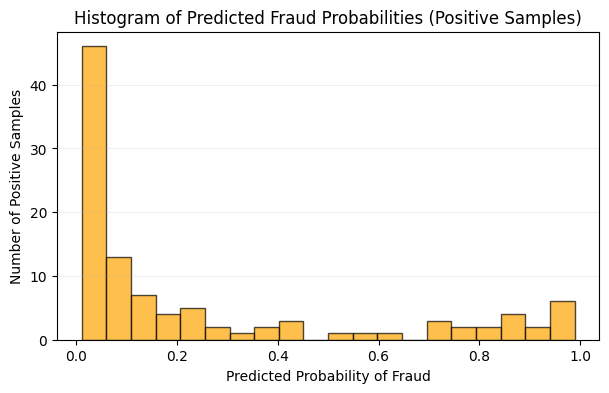

In [115]:
# Histogram of predicted fraud probabilities for positive (fraud) samples
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.hist(positive_probs['prob_fraud'], bins=20, color='orange', edgecolor='k', alpha=0.7)
plt.title('Histogram of Predicted Fraud Probabilities (Positive Samples)')
plt.xlabel('Predicted Probability of Fraud')
plt.ylabel('Number of Positive Samples')
plt.grid(axis='y', alpha=0.2)
plt.show()


**Observation:**

- More than half of the positive (fraud) validation samples have predicted fraud probabilities below 0.5.
- This means that, with the default threshold of 0.5, the model is missing many actual frauds (low recall for class 1).
- Lowering the threshold will increase recall (catch more frauds), but may also increase false positives (lower precision).
- This is a common issue in imbalanced classification and highlights the importance of threshold tuning for fraud detection.

#### ROC Curve vs. Precision-Recall (PR) Curve

- **ROC Curve (Receiver Operating Characteristic):**
    - Plots the True Positive Rate (Recall) against the False Positive Rate at various threshold settings.
    - Shows the trade-off between sensitivity (recall) and specificity (1 - false positive rate).
    - The Area Under the ROC Curve (AUC-ROC) is a common summary metric.
    - Useful for balanced datasets, but can be overly optimistic for imbalanced data.

- **Precision-Recall (PR) Curve:**
    - Plots Precision (positive predictive value) against Recall (sensitivity) at various thresholds.
    - Focuses on the performance for the positive (minority) class.
    - The Area Under the PR Curve (AUC-PR) is especially informative for imbalanced datasets.
    - More sensitive to changes in the minority class than ROC.

**Key Differences:**
- ROC curve considers all classes and is less informative when the positive class is rare.
- PR curve gives a more accurate picture of performance for the positive class in imbalanced problems (like fraud detection).

**Best Practice:**
- For imbalanced datasets, always examine the PR curve in addition to (or instead of) the ROC curve.
- Both curves help visualize model performance across thresholds, but the PR curve is usually more relevant for rare event detection.


#### Precision-Recall (PR) Curve Explained

- The PR curve plots **Precision** (y-axis) against **Recall** (x-axis) for different probability thresholds.
- **Precision** is the proportion of predicted positives that are actually positive: $\text{Precision} = \frac{TP}{TP + FP}$
- **Recall** (Sensitivity) is the proportion of actual positives that are correctly identified: $\text{Recall} = \frac{TP}{TP + FN}$
- Each point on the curve corresponds to a different threshold for classifying a sample as positive.
- The **area under the PR curve (AUC-PR)** summarizes the model's ability to balance precision and recall across thresholds.

**Why is the PR curve important for imbalanced data?**
- In imbalanced datasets (like fraud detection), the positive class is rare.
- The PR curve focuses on the performance for the positive class, making it more informative than the ROC curve in these cases.
- A high PR AUC means the model can achieve both high precision and high recall for the minority class.

**How to interpret the PR curve:**
- A curve closer to the top-right corner indicates better performance.
- If the curve is close to the baseline (the proportion of positives in the data), the model is not much better than random guessing.
- Use the PR curve to select a threshold that gives the desired trade-off between catching positives (recall) and minimizing false alarms (precision).

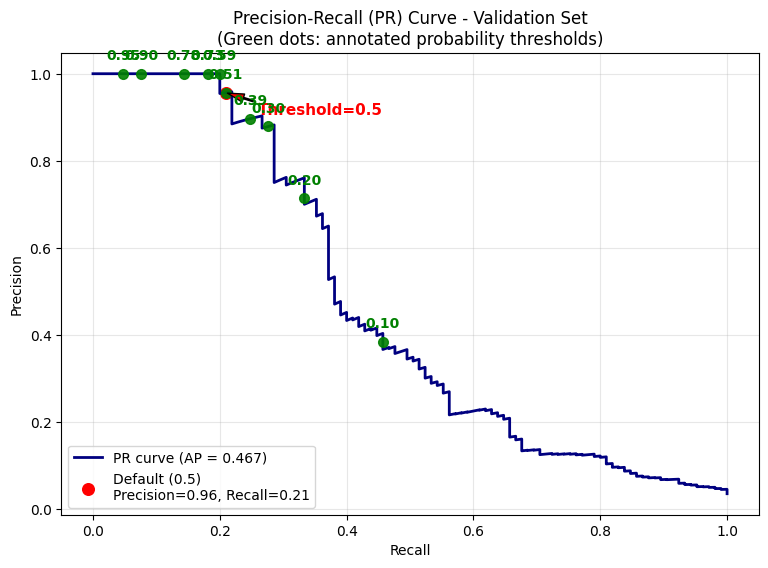

In [121]:
# Plot the Precision-Recall (PR) curve for the validation set, with selected annotated probability thresholds (.1, .2, ..., .95)
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, val_pred)
avg_precision = average_precision_score(y_val, val_pred)

# Default threshold (0.5) precision and recall
val_pred_label = (val_pred >= 0.5).astype(int)
def_prec = precision_score(y_val, val_pred_label)
def_rec = recall_score(y_val, val_pred_label)

plt.figure(figsize=(9,6))
plt.plot(recall, precision, color='navy', lw=2, label=f'PR curve (AP = {avg_precision:.3f})')
plt.scatter([def_rec], [def_prec], color='red', s=70, label=f'Default (0.5)\nPrecision={def_prec:.2f}, Recall={def_rec:.2f}')
plt.annotate('Threshold=0.5', xy=(def_rec, def_prec), xytext=(def_rec+0.05, def_prec-0.05),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=6), color='red', fontsize=11, weight='bold')

# Annotate only the specified probability thresholds
probs_to_annotate = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
for t_val in probs_to_annotate:
    if len(thresholds) > 0:
        idx = np.argmin(np.abs(thresholds - t_val))
        if idx < len(recall):
            plt.plot(recall[idx], precision[idx], marker='o', color='green', markersize=7, alpha=0.9)
            plt.annotate(f'{thresholds[idx]:.2f}', (recall[idx], precision[idx]), textcoords="offset points", xytext=(0,10), ha='center', color='green', fontsize=10, weight='bold')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (PR) Curve - Validation Set\n(Green dots: annotated probability thresholds)')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

In [122]:
# Find the 3 best probability cut-offs (thresholds) by F1 score
from sklearn.metrics import f1_score, precision_score, recall_score

precision, recall, thresholds = precision_recall_curve(y_val, val_pred)
f1s = []
for t in thresholds:
    preds = (val_pred >= t).astype(int)
    f1s.append(f1_score(y_val, preds))
f1s = np.array(f1s)

# Get indices of top 3 F1 scores
top3_idx = np.argsort(f1s)[-3:][::-1]

print("Top 3 probability thresholds by F1 score:")
for rank, idx in enumerate(top3_idx, 1):
    t = thresholds[idx]
    preds = (val_pred >= t).astype(int)
    p = precision_score(y_val, preds)
    r = recall_score(y_val, preds)
    f1 = f1s[idx]
    print(f"{rank}. Threshold: {t:.4f} | F1: {f1:.4f} | Precision: {p:.4f} | Recall: {r:.4f}")

Top 3 probability thresholds by F1 score:
1. Threshold: 0.1746 | F1: 0.4727 | Precision: 0.6500 | Recall: 0.3714
2. Threshold: 0.1799 | F1: 0.4720 | Precision: 0.6786 | Recall: 0.3619
3. Threshold: 0.1846 | F1: 0.4713 | Precision: 0.7115 | Recall: 0.3524


#### Other Machine Learning Methods for Fraud Detection

There are several other machine learning methods commonly used for fraud detection, each with its own strengths and use cases. Here’s a summary of the main categories and examples:

---

**1. Tree-Based Methods**
- **Decision Tree**: Simple, interpretable, but can overfit.
- **Random Forest**: Ensemble of decision trees, robust to overfitting, handles high-dimensional data.
- **Gradient Boosting Machines**: Includes XGBoost, LightGBM, CatBoost. Powerful for tabular data, handle missing values and categorical features well.

**2. Linear Models**
- **Logistic Regression**: Baseline for binary classification, interpretable, fast, but may underperform on complex data.
- **Linear Discriminant Analysis (LDA)**: Assumes normality, works well with well-separated classes.

**3. Support Vector Machines (SVM)**
- Effective for high-dimensional data, can use different kernels, but less scalable for large datasets.

**4. Neural Networks**
- **Multi-Layer Perceptron (MLP)**: Can model complex relationships, but requires more data and tuning.
- **Deep Learning Architectures**: Useful for large, complex datasets or when combining tabular with text/image data.

**5. k-Nearest Neighbors (k-NN)**
- Simple, non-parametric, but slow on large datasets and sensitive to feature scaling.

**6. Naive Bayes**
- Fast, works well with categorical data, but assumes feature independence.

**7. Anomaly Detection Methods**
- **Isolation Forest**: Detects outliers by random partitioning.
- **One-Class SVM**: Learns the boundary of normal data.
- **Autoencoders**: Neural networks that learn to reconstruct normal data, flagging high reconstruction error as anomalies.

**8. Ensemble Methods**
- **Bagging**: Combines predictions from multiple models to reduce variance.
- **Stacking**: Combines different types of models for improved performance.

**9. Unsupervised and Semi-Supervised Methods**
- Useful when labeled fraud data is scarce.
- **Clustering (e.g., K-Means)**: Groups similar transactions, outliers may be fraud.
- **Semi-supervised learning**: Uses small labeled and large unlabeled datasets.

---

**In practice:**
Tree-based ensemble methods (Random Forest, XGBoost, LightGBM, CatBoost) are most popular for tabular fraud detection, but combining them with anomaly detection or neural networks can further improve results, especially for rare-event detection.